# LCU Operator-Evolution Method for the Linear Pendulum

This notebook studies an operator-encoding approach to differential equations using the Linear Combination of Unitaries (LCU) method. The test problem is the linear pendulum,

$$
\ddot{x}+\omega^2x=0.
$$

In the earlier VQLS notebooks, each time step was formulated as a local linear system. Here, we instead write the time step as a linear update operator,

$$
u_{n+1}=Mu_n,
$$

and implement the generally non-unitary matrix $M$ using an LCU circuit.

The goal of this notebook is to:

1. derive the LCU decomposition of the Euler update matrix,
2. implement the LCU circuit in Qiskit,
3. verify the exact statevector/post-selection version,
4. study a measurement/QST-based implementation,
5. diagnose finite-shot and reconstruction errors,
6. clarify the relation between LCU, block encoding, and VQLS.

## Linear pendulum and Euler update

The linear pendulum equation is

$$
\ddot{x}+\omega^2x=0.
$$

Introducing $y=\dot{x}$, this becomes the first-order system

$$
\dot{x}=y,\qquad \dot{y}=-\omega^2x.
$$

Let

$$
u_n=
\begin{pmatrix}
x_n\\
y_n
\end{pmatrix}.
$$

Using forward Euler with step size $h$,

$$
x_{n+1}=x_n+h y_n,
$$

$$
y_{n+1}=y_n-h\omega^2x_n.
$$

Therefore,
$
u_{n+1}=Mu_n,
$

where

$$
M= \begin{pmatrix}
1 & h\\
-h\omega^2 & 1
\end{pmatrix}=
I+h
\begin{pmatrix}
0 & 1\\
-\omega^2 & 0
\end{pmatrix}.
$$

The matrix $M$ is generally non-unitary, so it cannot be directly applied as a quantum gate. The LCU method provides a way to embed this non-unitary update into a larger unitary circuit using ancillas and post-selection.

## LCU decomposition of the Euler update matrix

The goal is to express the non-unitary Euler update matrix $M$ as a linear combination of unitary operators,

$$
M=\sum_j c_j U_j,
$$

where $c_j\ge 0$ and each $U_j$ is unitary.

For the linear pendulum,

$$
M=
\begin{pmatrix}
1 & h\\
-h\omega^2 & 1
\end{pmatrix}.
$$

We write

$$
M=I+bX+cZX,
$$

where

$$
X=
\begin{pmatrix}
0&1\\
1&0
\end{pmatrix},
\qquad
ZX=
\begin{pmatrix}
0&1\\
-1&0
\end{pmatrix}.
$$

Then

$$
bX+cZX
=\begin{pmatrix}
0&b+c\\
b-c&0
\end{pmatrix}.
$$

Matching this with

$$
M-I=
\begin{pmatrix}
0&h\\
-h\omega^2&0
\end{pmatrix},
$$

we require
$
b+c=h,
\qquad
b-c=-h\omega^2.
$

Solving gives
$$
b=\frac{h(1-\omega^2)}{2},
\qquad
c=\frac{h(1+\omega^2)}{2}.
$$

Since $b$ can be negative, we write
$
bX=|b|\,\operatorname{sign}(b)X.
$
Thus the LCU form is

$$
M=c_0U_0+c_1U_1+c_2U_2,
$$

with
$
c_0=1,\qquad c_1=|b|,\qquad c_2=c,
$

and

$
U_0=I,\qquad
U_1=\operatorname{sign}(b)X,\qquad
U_2=ZX.
$

The LCU normalization is

$
\alpha=c_0+c_1+c_2.
$

The classical vector $u_n=(x_n,y_n)^T$ is encoded as the one-qubit state

$$
|\psi_n\rangle
= \frac{x_n|0\rangle+y_n|1\rangle}
{\sqrt{x_n^2+y_n^2}}.
$$

The classical norm
$
\|u_n\|=\sqrt{x_n^2+y_n^2}
$
is tracked separately.

Since the state is real, it can be prepared using a single $R_y$ rotation:

$$
R_y(\theta_n)|0\rangle
=\cos\frac{\theta_n}{2}|0\rangle
+
\sin\frac{\theta_n}{2}|1\rangle.
$$

Thus,
$
\theta_n=2\arctan2(y_n,x_n).
$

The LCU circuit implements the unnormalized post-selected branch

$$
\frac{M|\psi_n\rangle}{\alpha}.
$$

Therefore, to recover the classical Euler update,
$
u_{n+1}=Mu_n,
$
we multiply the post-selected amplitudes by
$
\alpha \|u_n\|.
$

## Imports and Helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import XGate, ZGate
from qiskit_aer import AerSimulator

In [2]:
DEFAULT_SEED = 1234

## Classical Euler Solver

In [3]:
#Function to find classical solution
def classical_euler_linear_pendulum(h, omega, x0, y0, n_steps):
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(n_steps):
        x_next = x + h * y
        y_next = y - h * omega**2 * x

        x, y = x_next, y_next
        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h
    return t_vals, np.array(x_vals), np.array(y_vals)

## LCU circuit construction

The below function returns the LCU coefficients for the Euler update matrix $M$

In [6]:
#Function to obtain the coefficients of unitarities given h and omega
def lcu_coefficients_linear_pendulum(h, omega):
    b = h * (1 - omega**2) / 2
    c = h * (1 + omega**2) / 2

    c0 = 1.0
    c1 = abs(b)
    c2 = c

    alpha = c0 + c1 + c2
    sign_b = 1 if b >= 0 else -1

    return c0, c1, c2, alpha, sign_b

The LCU circuit has the structure

$$
W=
(\mathrm{PREPARE}^{\dagger}\otimes I)
\,
\mathrm{SELECT}
\,
(\mathrm{PREPARE}\otimes I).
$$

The two ancilla qubits label the three unitary terms:

$$
|00\rangle \rightarrow U_0=I,
$$

$$
|01\rangle \rightarrow U_1=\operatorname{sign}(b)X,
$$

$$
|10\rangle \rightarrow U_2=ZX.
$$

The fourth branch $|11\rangle$ is unused.

The PREPARE operation creates

$$
|a\rangle
=\sqrt{\frac{c_0}{\alpha}}|00\rangle
+
\sqrt{\frac{c_1}{\alpha}}|01\rangle
+
\sqrt{\frac{c_2}{\alpha}}|10\rangle.
$$

The SELECT operation applies the corresponding unitary to the system qubit,

$$
\mathrm{SELECT}
=|00\rangle\langle 00|\otimes U_0
+
|01\rangle\langle 01|\otimes U_1
+
|10\rangle\langle 10|\otimes U_2.
$$

After applying $\mathrm{PREPARE}^{\dagger}$, the $|00\rangle$ ancilla branch contains

$$
\frac{M|\psi\rangle}{\alpha}.
$$

Therefore,

$$
(\langle 00|\otimes I)W(|00\rangle\otimes I)
=\frac{M}{\alpha}.
$$

This is also a block encoding of $M/\alpha$.

In [9]:
def create_lcu_circuit_linear_pendulum(theta_init, h, omega):
    c0, c1, c2, alpha, sign_b = lcu_coefficients_linear_pendulum(h, omega)

    p0 = c0 / alpha
    p1 = c1 / alpha
    p2 = c2 / alpha

    a0 = 0
    a1 = 1
    s = 2

    qc = QuantumCircuit(3)

    # Prepare system state on q2.
    qc.ry(theta_init, s)
    qc.barrier()

    # ----------------------------
    # PREPARE ancilla state
    # ----------------------------
    theta0 = 2 * np.arcsin(np.sqrt(p2))
    qc.ry(theta0, a0)

    p_sum = p0 + p1
    theta1 = 2 * np.arcsin(np.sqrt(p1 / p_sum)) if p_sum > 0 else 0.0

    # Controlled rotation on a1 conditioned on a0=0.
    qc.x(a0)
    qc.cry(theta1, a0, a1)
    qc.x(a0)

    qc.barrier()
    # ----------------------------
    # SELECT operation
    # ----------------------------

    # Branch |01> applies U1 = sign(b) X.
    # Convert control branch |01> to |11> by flipping a0.
    qc.x(a0)

    if sign_b == 1:
        qc.append(XGate().control(2, ctrl_state="11"), [a0, a1, s])
    else:
        # Implement -X using Z X Z = -X.
        qc.append(ZGate().control(2, ctrl_state="11"), [a0, a1, s])
        qc.append(XGate().control(2, ctrl_state="11"), [a0, a1, s])
        qc.append(ZGate().control(2, ctrl_state="11"), [a0, a1, s])

    qc.x(a0)

    qc.barrier()

    # Branch |10> applies U2 = ZX.
    # Convert control branch |10> to |11> by flipping a1.
    qc.x(a1)
    qc.append(XGate().control(2, ctrl_state="11"), [a0, a1, s])
    qc.append(ZGate().control(2, ctrl_state="11"), [a0, a1, s])
    qc.x(a1)

    qc.barrier()
    # ----------------------------
    # UNPREPARE ancilla state
    # ----------------------------
    qc.x(a0)
    qc.cry(-theta1, a0, a1)
    qc.x(a0)

    qc.ry(-theta0, a0)

    return qc, alpha

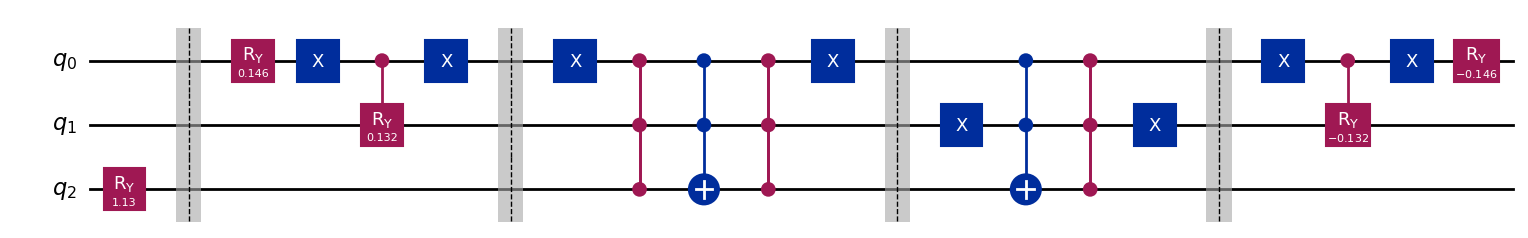

In [10]:
#Testing
test_theta = 2 * np.arctan2(1.0, np.pi / 2)
qc_test, alpha_test = create_lcu_circuit_linear_pendulum(
    test_theta, h=0.001, omega=np.sqrt(9.8)
)

qc_test.draw("mpl")

The circuit contains three conceptual parts: ancilla preparation, controlled unitary selection, and inverse ancilla preparation. The final post-selection on ancillas $|00\rangle$ extracts the desired non-unitary update.

# Exact statevector post-selection

In the statevector implementation, we directly access the final state amplitudes. This allows us to extract the unnormalized post-selected branch corresponding to ancillas $|00\rangle$.

With the qubit ordering

$$
q_0,q_1=\text{ancillas},\qquad q_2=\text{system},
$$

Qiskit's little-endian convention gives:

- index $0$: ancillas $|00\rangle$, system $|0\rangle$,
- index $4$: ancillas $|00\rangle$, system $|1\rangle$.

The successful branch is

$$
\frac{M|\psi_n\rangle}{\alpha}.
$$

Multiplying by $\alpha\|u_n\|$ gives the classical Euler vector $Mu_n$.

In [11]:
#Function to define obtain solution vector at one time step
def lcu_step_statevector(x, y, h, omega):
    norm = np.sqrt(x**2 + y**2)

    if norm == 0:
        return 0.0, 0.0

    theta = 2 * np.arctan2(y, x)

    qc, alpha = create_lcu_circuit_linear_pendulum(theta, h, omega)

    state = Statevector(qc).data

    # With q0,q1 as ancillas and q2 as system:
    # index 0 = |q2 q1 q0> = |000>
    # index 4 = |100>, i.e. system q2=1 and ancillas q0=q1=0.
    x_next = np.real(state[0] * alpha * norm)
    y_next = np.real(state[4] * alpha * norm)

    return x_next, y_next

In [12]:
#Function to obtain the full trajectory 
def lcu_trajectory_statevector(h, omega, x0, y0, n_steps):
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(n_steps):
        x, y = lcu_step_statevector(x, y, h, omega)
        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h
    return t_vals, np.array(x_vals), np.array(y_vals)

In [13]:
#Testing
h = 0.001
omega = np.sqrt(9.8)
x0 = np.pi / 2
y0 = 1.0
n_steps = 1000

t_cl, x_cl, y_cl = classical_euler_linear_pendulum(h, omega, x0, y0, n_steps)
t_lcu, x_lcu, y_lcu = lcu_trajectory_statevector(h, omega, x0, y0, n_steps)


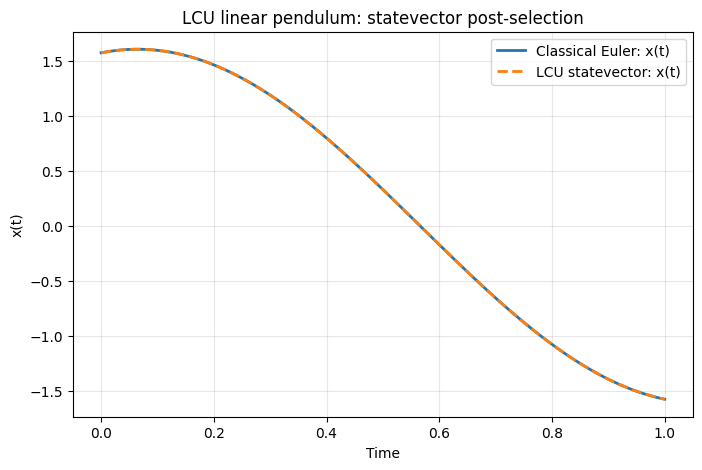

In [14]:
#x(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl, x_cl, label="Classical Euler: x(t)", linewidth=2)
plt.plot(t_lcu, x_lcu, "--", label="LCU statevector: x(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("LCU linear pendulum: statevector post-selection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

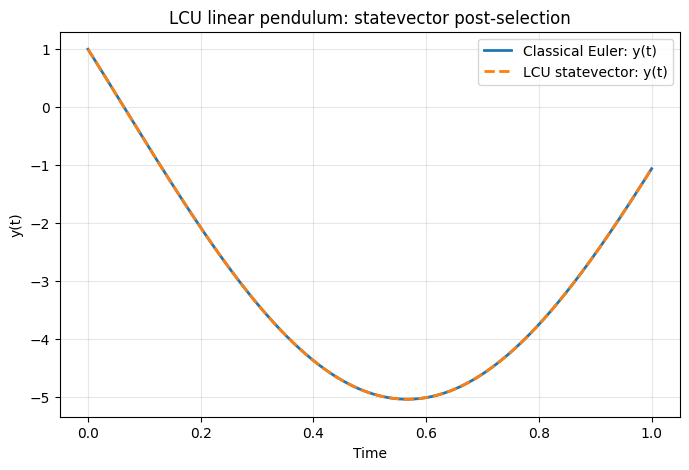

In [15]:
#y(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl, y_cl, label="Classical Euler: y(t)", linewidth=2)
plt.plot(t_lcu, y_lcu, "--", label="LCU statevector: y(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("LCU linear pendulum: statevector post-selection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

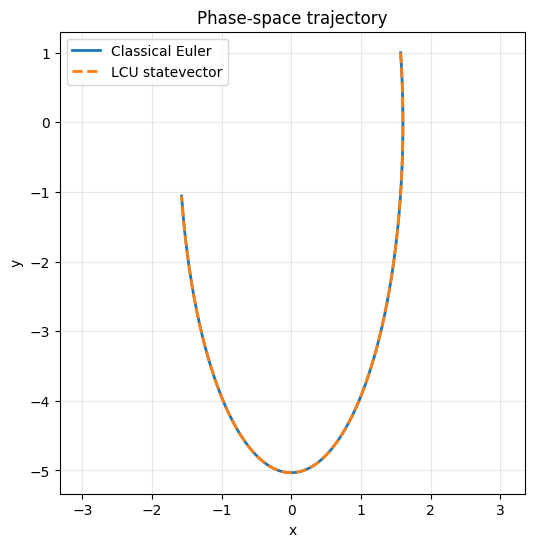

In [16]:
#Phase space Plot
plt.figure(figsize=(6, 6))
plt.plot(x_cl, y_cl, label="Classical Euler", linewidth=2)
plt.plot(x_lcu, y_lcu, "--", label="LCU statevector", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase-space trajectory")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

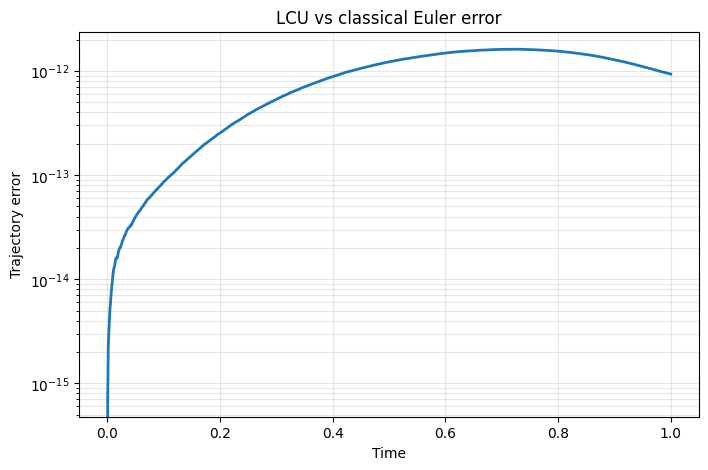

In [17]:
#Trajectory error Plots
trajectory_error = np.sqrt((x_lcu - x_cl)**2 + (y_lcu - y_cl)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl, trajectory_error, linewidth=2)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("LCU vs classical Euler error")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [18]:
print("Max trajectory error:", np.max(trajectory_error))

Max trajectory error: 1.6202966248115663e-12


The maximum trajectory error is at the level of numerical precision. This verifies that the LCU circuit implements the same Euler update matrix as the classical calculation when exact statevector amplitudes are available.

# Measurement/QST version

The exact statevector implementation is useful for validation, but it assumes direct access to amplitudes. A measurement-based implementation must reconstruct the post-selected system state from measurement statistics.

For this one-qubit real-valued example, we use measurements in the $Z$ and $X$ bases.

After the LCU circuit, we post-select the ancilla outcome $|00\rangle$. Conditional on this successful outcome, the system state is approximately

$$
|\psi_{n+1}\rangle=a|0\rangle+b|1\rangle,
\qquad a,b\in\mathbb{R}.
$$

The $Z$-basis measurement gives

$$
\langle Z\rangle=a^2-b^2.
$$

The $X$-basis measurement gives

$$
\langle X\rangle=2ab.
$$

Thus, for a real one-qubit state,

$$
a=\sqrt{\frac{1+\langle Z\rangle}{2}},
$$

$$
b=\operatorname{sign}(\langle X\rangle)
\sqrt{\frac{1-\langle Z\rangle}{2}},
$$

up to an overall global sign.

For a general complex one-qubit state, a $Y$-basis measurement would also be required. Here the state and the update matrix are real, so $X$ and $Z$ are sufficient.

In [19]:
def measured_circuit_explicit(qc, basis="Z"):
    qc_m = qc.copy()
    basis = basis.upper()

    if basis == "X":  #apply H to system before measurement
        qc_m.h(2)
    elif basis == "Y":  #apply Sdg then H to system before measurement
        qc_m.sdg(2)
        qc_m.h(2)
    elif basis != "Z":
        raise ValueError("basis must be 'X', 'Y', or 'Z'")

    cr = ClassicalRegister(3, "c")
    qc_m.add_register(cr)

    qc_m.measure(0, cr[0]) #ancilla 0
    qc_m.measure(1, cr[1]) #ancilla 1
    qc_m.measure(2, cr[2]) #system

    return qc_m


    Compute expectation value of the measured basis observable
    after post-selecting ancillas q0=q1=0.

    With explicit measurement q0->c0, q1->c1, q2->c2,
    counts keys are c2 c1 c0.

    Successful ancilla outcomes:
        system 0: '000'
        system 1: '100'


In [20]:
def get_bit(count_key, classical_bit_index):
    """
    Qiskit count strings are displayed with the highest classical bit on the left.
    If the key is c2 c1 c0, then classical bit c_i is key[-1-i].
    """
    key = count_key.replace(" ", "")
    return key[-1 - classical_bit_index]


In [21]:
def postselected_expectation_from_counts( counts, ancilla_cbits=(0, 1), system_cbit=2):
    n0 = 0
    n1 = 0
    total_shots = sum(counts.values())

    for key, value in counts.items():
        ancilla_success = all(
            get_bit(key, cbit) == "0" for cbit in ancilla_cbits
        )

        if ancilla_success:
            system_bit = get_bit(key, system_cbit)

            if system_bit == "0":
                n0 += value
            elif system_bit == "1":
                n1 += value

    n_success = n0 + n1

    if n_success == 0:
        return None, 0.0, n0, n1

    expectation = (n0 - n1) / n_success
    p_success = n_success / total_shots

    return expectation, p_success, n0, n1

## Reconstructing the real one-qubit state

For a real pure state,

$$
|\psi\rangle=a|0\rangle+b|1\rangle,
$$

the ideal expectation values satisfy

$$
\langle X\rangle^2+\langle Z\rangle^2=1.
$$

Finite-shot estimates generally do not satisfy this relation exactly. We therefore consider two reconstruction methods:

1. **Raw reconstruction:** directly uses the measured $\langle X\rangle$ and $\langle Z\rangle$.
2. **Stable reconstruction:** first normalizes the measured $(\langle X\rangle,\langle Z\rangle)$ vector back to the unit circle before reconstructing the amplitudes.

The stable reconstruction reduces unphysical drift caused by finite-shot noise.

In [22]:
#Function to creating amplitudes of state vector
def reconstruct_real_state_from_xz_raw(exp_z, exp_x):
    # numerical clipping
    exp_z = np.clip(exp_z, -1.0, 1.0)
    exp_x = np.clip(exp_x, -1.0, 1.0)

    a = np.sqrt((1 + exp_z) / 2)
    b_abs = np.sqrt((1 - exp_z) / 2)

    if abs(a) < 1e-12:
        # If a is nearly zero, X gives little sign information.
        b = b_abs
    else:
        b = np.sign(exp_x) * b_abs

    return np.array([a, b])

In [23]:
#Another way to reconstruct real state
def reconstruct_real_state_from_xz_stable(exp_z, exp_x):
    r = np.sqrt(exp_x**2 + exp_z**2)

    if r > 1e-12:
        exp_x = exp_x / r
        exp_z = exp_z / r

    exp_z = np.clip(exp_z, -1.0, 1.0)

    a = np.sqrt((1 + exp_z) / 2)
    b_abs = np.sqrt((1 - exp_z) / 2)
    b = np.sign(exp_x) * b_abs

    return np.array([a, b])

In [24]:
def reconstruct_real_state_from_xz(exp_z, exp_x, method="stable"):
    if method == "raw":
        return reconstruct_real_state_from_xz_raw(exp_z, exp_x)
    if method == "stable":
        return reconstruct_real_state_from_xz_stable(exp_z, exp_x)
    raise ValueError("method must be 'raw' or 'stable'")

Perform one measurement/QST-based LCU step.
    
    The LCU circuit is run twice:
        1. Z-basis measurement for <Z> and success probability.
        2. X-basis measurement for <X>.

    The post-selected system state is reconstructed from <X> and <Z>.

In [43]:
def lcu_step_qst(x,y,h,omega,shots=20000,simulator=None,sign_fix="continuity",reconstruction="stable"):
    if simulator is None:
        simulator = AerSimulator()

    norm_prev = np.sqrt(x**2 + y**2)

    if norm_prev == 0:
        return 0.0, 0.0, {
            "p_success_z": 0.0,
            "p_success_x": 0.0,
            "exp_z": None,
            "exp_x": None,
            "n_success_z": 0,
            "n_success_x": 0
        }

    theta = 2 * np.arctan2(y, x)

    # Build LCU circuit
    qc, alpha = create_lcu_circuit_linear_pendulum(theta, h, omega)

    # Z-basis measurement
    qc_z = measured_circuit_explicit(qc, basis="Z")
    tqc_z = transpile(qc_z, simulator)
    counts_z = simulator.run(tqc_z, shots=shots).result().get_counts()

    exp_z, p_success_z,n0_z,n1_z = postselected_expectation_from_counts(counts_z)

    # X-basis measurement
    qc_x = measured_circuit_explicit(qc, basis="X")
    tqc_x = transpile(qc_x, simulator)
    counts_x = simulator.run(tqc_x, shots=shots).result().get_counts()

    exp_x, p_success_x, n0_x, n1_x = postselected_expectation_from_counts(counts_x)

    if exp_z is None or exp_x is None:
        raise RuntimeError("No successful post-selected shots. Increase shots or check circuit.")

    # Reconstruct normalized post-selected state
    psi_next = reconstruct_real_state_from_xz(exp_z, exp_x, method=reconstruction)

    # Use Z-basis success probability for norm update.
    # X-basis should give similar success probability up to shot noise.
    p_success = p_success_z

    norm_next = alpha * np.sqrt(p_success) * norm_prev

    u_next = norm_next * psi_next

    # Fixing global sign by continuity if desired
    if sign_fix == "continuity":
        prev_vec = np.array([x, y])
        if np.dot(u_next, prev_vec) < 0:
            u_next = -u_next

    diagnostics = {
        "alpha": alpha,
        "p_success_z": p_success_z,
        "p_success_x": p_success_x,
        "exp_z": exp_z,
        "exp_x": exp_x,
        "bloch_xz_norm": np.sqrt(exp_x**2 + exp_z**2),
        "n0_z": n0_z,
        "n1_z": n1_z,
        "n0_x": n0_x,
        "n1_x": n1_x,
        "n_success_z": n0_z + n1_z,
        "n_success_x": n0_x + n1_x
    }

    return u_next[0], u_next[1], diagnostics

Full pendulum trajectory

In [44]:
def lcu_trajectory_qst(h,omega, x0, y0,n_steps,shots=20000, seed_simulator=1234,reconstruction="stable"):
   
    simulator = AerSimulator(seed_simulator=seed_simulator)
    
    x_vals = [x0]
    y_vals = [y0]

    diagnostics = []

    x, y = x0, y0

    for step in range(n_steps):
        x, y, diag = lcu_step_qst(x,y,h,omega,shots=shots,simulator=simulator,reconstruction=reconstruction)

        x_vals.append(x)
        y_vals.append(y)
        diagnostics.append(diag)

    t_vals = np.arange(n_steps + 1) * h

    return t_vals, np.array(x_vals), np.array(y_vals), diagnostics

We will try to check the validty of the method by obtaining the solution for one time step 

In [30]:
# One-step comparison
h = 0.001
omega = np.sqrt(9.8)
x0 = np.pi / 2
y0 = 1.0

x = x0
y = y0

x_cl_1 = x + h*y
y_cl_1 = y - h*omega**2*x

x_sv_1, y_sv_1 = lcu_step_statevector(x, y, h, omega)
x_qst_1, y_qst_1, diag = lcu_step_qst(x, y, h, omega, shots=200000)

one_step_error = np.sqrt((x_qst_1 - x_cl_1)**2 + (y_qst_1 - y_cl_1)**2)

print("Classical:", x_cl_1, y_cl_1)
print("Statevector:", x_sv_1, y_sv_1)
print("QST:", x_qst_1, y_qst_1)
print(f"One-step QST vector error: {one_step_error:.3e}")
print("exp_z:", diag["exp_z"])
print("exp_x:", diag["exp_x"])
print("Bloch XZ norm:", diag["bloch_xz_norm"])
print("p_success_z:", diag["p_success_z"])
print("p_success_x:", diag["p_success_x"])
print("alpha:", diag["alpha"])


Classical: 1.5717963267948964 0.9846061959974101
Statevector: 1.5717963267948962 0.9846061959974094
QST: 1.5728018668728385 0.9830844191010135
One-step QST vector error: 1.824e-03
exp_z: 0.43837488951468684
exp_x: 0.899404361165787
Bloch XZ norm: 1.0005502229478795
p_success_z: 0.97298
p_success_x: 0.972905
alpha: 1.0098


The statevector result matches the classical Euler update up to numerical precision. The QST result is close, but contains finite-shot error. Since the QST output is recursively used as the input for the next step, small one-step errors can accumulate over time. 

## Varying seeds

In [31]:
seed_results = []

for seed in range(1, 11):
    sim = AerSimulator(seed_simulator=seed)
    x_qst, y_qst, diag = lcu_step_qst(
        x0, y0, h, omega, shots=100000, simulator=sim
    )

    err = np.sqrt((x_qst - x_cl_1)**2 + (y_qst - y_cl_1)**2)

    seed_results.append([seed, x_qst, y_qst, err, diag["p_success_z"]])

seed_results = np.array(seed_results)

print("Mean one-step error:", np.mean(seed_results[:, 3]))
print("Std one-step error:", np.std(seed_results[:, 3]))

Mean one-step error: 0.002928393996764229
Std one-step error: 0.0013904914115690328


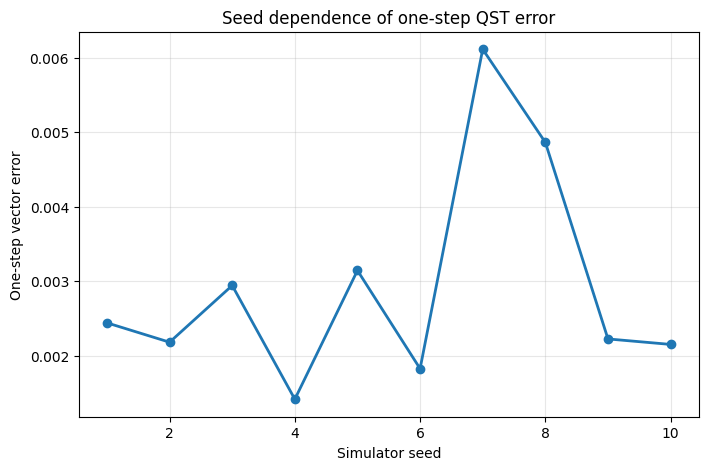

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(seed_results[:, 0], seed_results[:, 3], "o-", linewidth=2)
plt.xlabel("Simulator seed")
plt.ylabel("One-step vector error")
plt.title("Seed dependence of one-step QST error")
plt.grid(True, alpha=0.3)
plt.show()

The one-step QST output varies with the simulator seed, confirming that the discrepancy is dominated by finite-shot sampling noise rather than a deterministic error in the circuit.

In [33]:
#Testing for higher shots and less steps
h = 0.001
omega = np.sqrt(9.8)
x0 = np.pi / 2
y0 = 1.0

n_steps = 20
shots = 1000000

t_cl, x_cl, y_cl = classical_euler_linear_pendulum(
    h, omega, x0, y0, n_steps
)

t_qst, x_qst, y_qst, diag_qst = lcu_trajectory_qst(
    h, omega, x0, y0, n_steps, shots=shots
)

## Plotting Trajectories

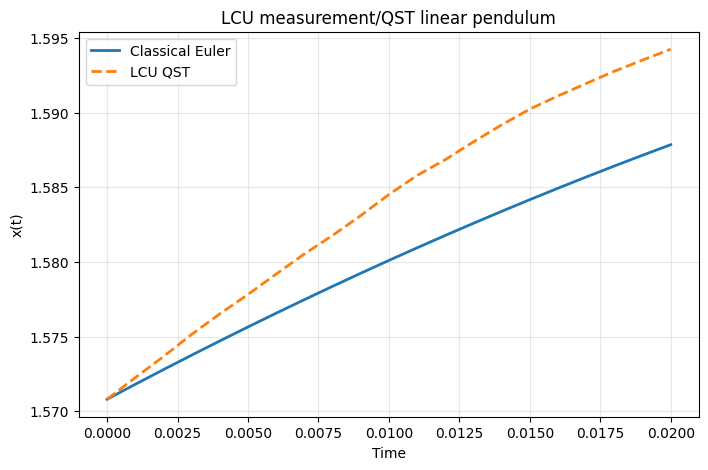

In [34]:
#plotting x(t)
plt.figure(figsize=(8, 5))
plt.plot(t_cl, x_cl, label="Classical Euler", linewidth=2)
plt.plot(t_qst, x_qst, "--", label="LCU QST", linewidth=2)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("LCU measurement/QST linear pendulum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


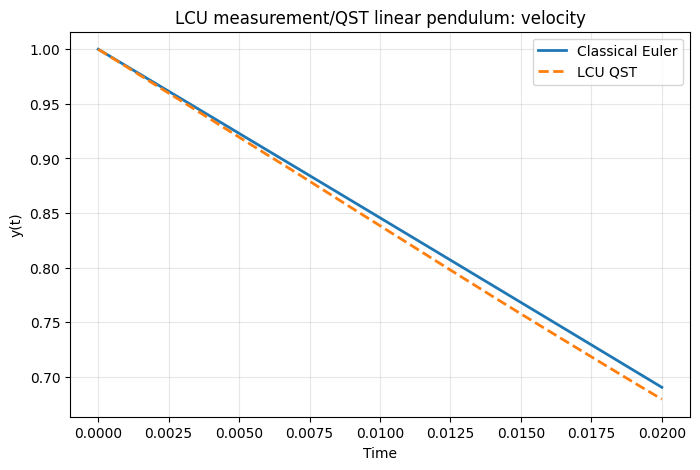

In [35]:
#Plotting y(t)
plt.figure(figsize=(8, 5))
plt.plot(t_cl, y_cl, label="Classical Euler", linewidth=2)
plt.plot(t_qst, y_qst, "--", label="LCU QST", linewidth=2)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("LCU measurement/QST linear pendulum: velocity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

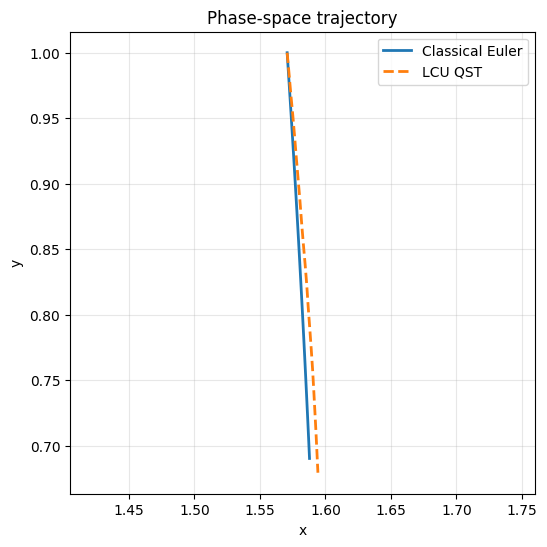

In [36]:
#Phase sapce trajectory
plt.figure(figsize=(6, 6))
plt.plot(x_cl, y_cl, label="Classical Euler", linewidth=2)
plt.plot(x_qst, y_qst, "--", label="LCU QST", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase-space trajectory")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

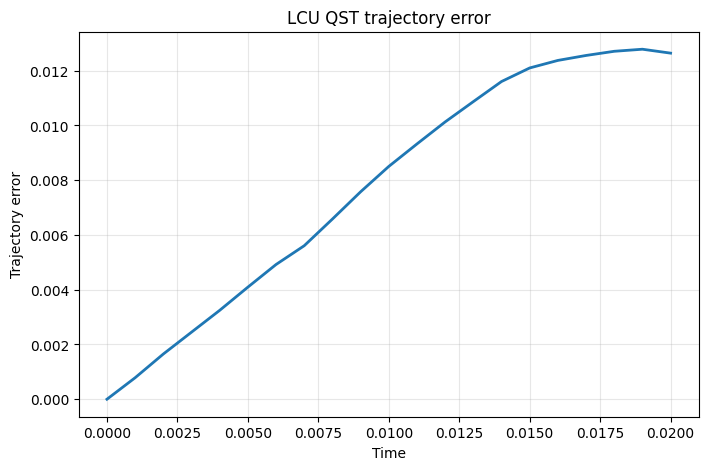

Final trajectory error: 1.264e-02
Maximum trajectory error: 1.278e-02


In [37]:
#Trajectory Error plot
traj_error = np.sqrt((x_qst - x_cl)**2 + (y_qst - y_cl)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl, traj_error, linewidth=2)
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("LCU QST trajectory error")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final trajectory error: {traj_error[-1]:.3e}")
print(f"Maximum trajectory error: {np.max(traj_error):.3e}")

## Post-Selection Probabilities

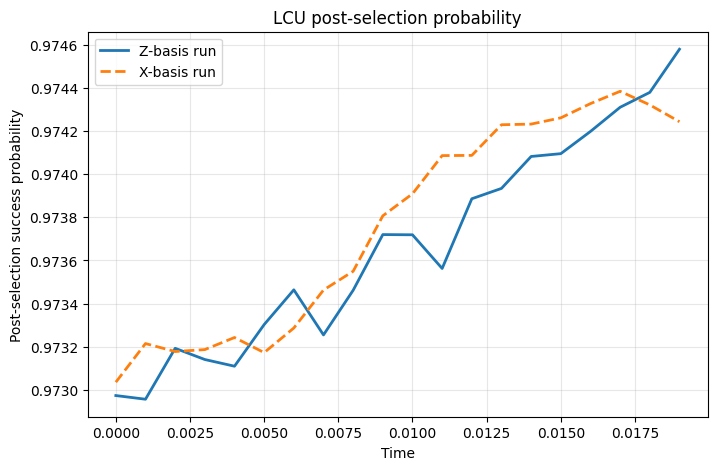

Mean success probability (Z): 0.9736661999999999
Minimum success probability (Z): 0.972957
Mean |p_z - p_x|: 0.0001663000000000081


In [38]:
#Post-selection probabilities
p_success_z_vals = np.array([d["p_success_z"] for d in diag_qst])
p_success_x_vals = np.array([d["p_success_x"] for d in diag_qst])

plt.figure(figsize=(8, 5))
plt.plot(t_cl[:-1], p_success_z_vals, label="Z-basis run", linewidth=2)
plt.plot(t_cl[:-1], p_success_x_vals, "--", label="X-basis run", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Post-selection success probability")
plt.title("LCU post-selection probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Mean success probability (Z):", np.mean(p_success_z_vals))
print("Minimum success probability (Z):", np.min(p_success_z_vals))
print("Mean |p_z - p_x|:", np.mean(np.abs(p_success_z_vals - p_success_x_vals)))

The $Z$- and $X$-basis circuits should have the same post-selection probability in the infinite-shot limit. Small differences between them are another indicator of finite-shot noise.

## Shot scaling of QST trajectory error

In [39]:
def run_qst_shot_scaling(shots_list, h, omega, x0, y0, n_steps, seed=1234):
    t_cl, x_cl, y_cl = classical_euler_linear_pendulum(
        h, omega, x0, y0, n_steps
    )

    results = []

    for shots in shots_list:
        t_qst, x_qst, y_qst, diag_qst = lcu_trajectory_qst(
            h,
            omega,
            x0,
            y0,
            n_steps,
            shots=shots,
            seed_simulator=seed,
            reconstruction="stable"
        )

        traj_error = np.sqrt((x_qst - x_cl)**2 + (y_qst - y_cl)**2)

        results.append({
            "shots": shots,
            "max_error": np.max(traj_error),
            "final_error": traj_error[-1],
            "mean_success_probability": np.mean([d["p_success_z"] for d in diag_qst])
        })

    return results

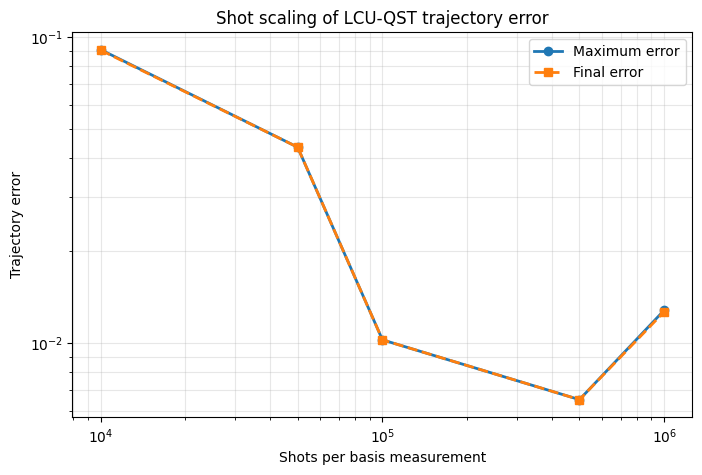

In [40]:
shots_list = [10_000, 50_000, 100_000, 500_000, 1_000_000]
n_steps_scaling = 20

shot_results = run_qst_shot_scaling(
    shots_list, h, omega, x0, y0, n_steps_scaling
)

shots_arr = np.array([r["shots"] for r in shot_results])
max_err_arr = np.array([r["max_error"] for r in shot_results])
final_err_arr = np.array([r["final_error"] for r in shot_results])

plt.figure(figsize=(8, 5))
plt.loglog(shots_arr, max_err_arr, "o-", label="Maximum error", linewidth=2)
plt.loglog(shots_arr, final_err_arr, "s--", label="Final error", linewidth=2)
plt.xlabel("Shots per basis measurement")
plt.ylabel("Trajectory error")
plt.title("Shot scaling of LCU-QST trajectory error")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## Raw versus stable QST reconstruction

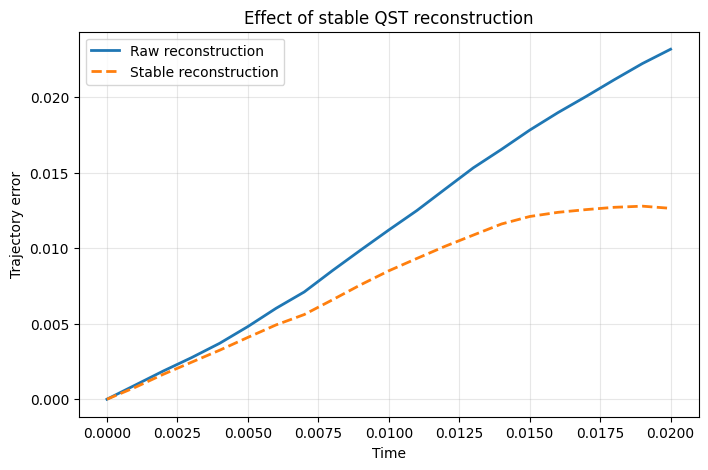

In [45]:
shots_compare = 1_000_000
n_steps_compare = 20

t_raw, x_raw, y_raw, diag_raw = lcu_trajectory_qst(
    h,
    omega,
    x0,
    y0,
    n_steps_compare,
    shots=shots_compare,
    seed_simulator=DEFAULT_SEED,
    reconstruction="raw"
)

t_stable, x_stable, y_stable, diag_stable = lcu_trajectory_qst(
    h,
    omega,
    x0,
    y0,
    n_steps_compare,
    shots=shots_compare,
    seed_simulator=DEFAULT_SEED,
    reconstruction="stable"
)

t_cl_cmp, x_cl_cmp, y_cl_cmp = classical_euler_linear_pendulum(
    h, omega, x0, y0, n_steps_compare
)

err_raw = np.sqrt((x_raw - x_cl_cmp)**2 + (y_raw - y_cl_cmp)**2)
err_stable = np.sqrt((x_stable - x_cl_cmp)**2 + (y_stable - y_cl_cmp)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl_cmp, err_raw, label="Raw reconstruction", linewidth=2)
plt.plot(t_cl_cmp, err_stable, "--", label="Stable reconstruction", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("Effect of stable QST reconstruction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The stable reconstruction reduces the effect of finite-shot fluctuations by projecting the measured $(\langle X\rangle,\langle Z\rangle)$ vector back onto the unit circle before converting it into amplitudes.

## Bloch Vector Inconsistiency

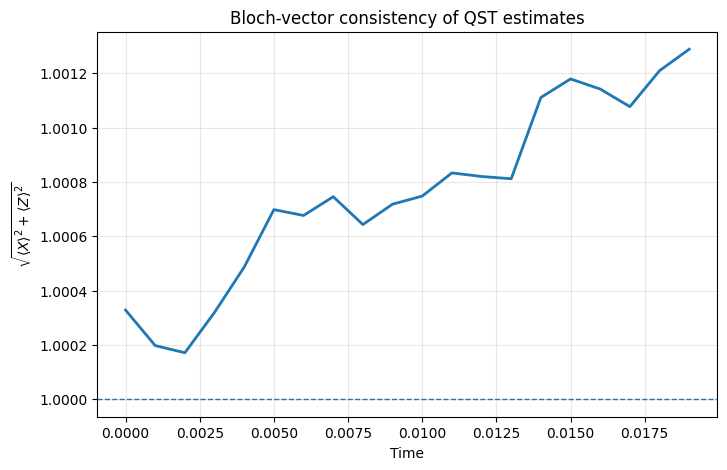

In [46]:
#Bloch-vector Consistency
bloch_norms = np.array([
    d["bloch_xz_norm"] for d in diag_qst])

plt.figure(figsize=(8, 5))
plt.plot(t_cl[:-1], bloch_norms, linewidth=2)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel(r"$\sqrt{\langle X\rangle^2+\langle Z\rangle^2}$")
plt.title("Bloch-vector consistency of QST estimates")
plt.grid(True, alpha=0.3)
plt.show()

For an ideal real one-qubit pure state, the Bloch-vector components satisfy

$$
\langle X\rangle^2+\langle Z\rangle^2=1.
$$

Finite-shot estimates fluctuate around this value. Deviations from 1 quantify the inconsistency introduced by sampling noise.

## Norm Evolution

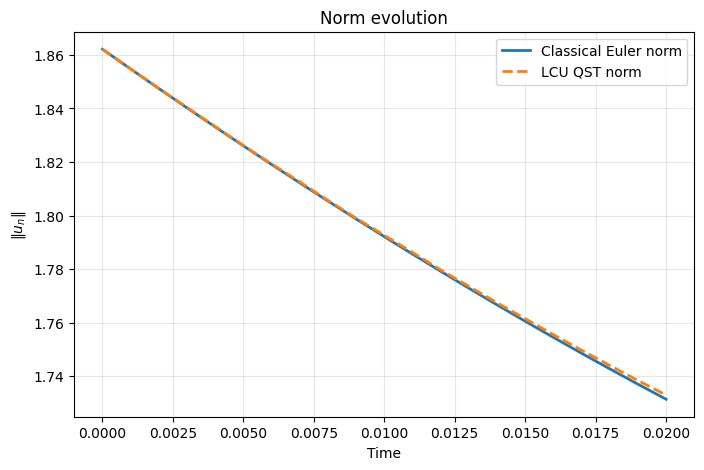

In [47]:
norm_cl = np.sqrt(x_cl**2 + y_cl**2)
norm_qst = np.sqrt(x_qst**2 + y_qst**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl, norm_cl, label="Classical Euler norm", linewidth=2)
plt.plot(t_qst, norm_qst, "--", label="LCU QST norm", linewidth=2)
plt.xlabel("Time")
plt.ylabel(r"$\|u_n\|$")
plt.title("Norm evolution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The QST method reconstructs the direction of the state from $X$- and $Z$-basis measurements, while the norm is updated using the post-selection probability. This plot checks whether the measurement-based norm update tracks the classical Euler norm.

# Relation to VQLS and block encoding

This LCU method is complementary to the VQLS approach.

In the VQLS route, the differential equation is discretized into a local linear system,

$$
A_n u_{n+1}=b_n,
$$

and a variational quantum algorithm is used to prepare a state proportional to the solution.

In the LCU route, the time step is written as an operator update,
$
u_{n+1}=Mu_n,
$
and the update operator $M$ is encoded as a linear combination of unitary operations.

Thus,

$$
\text{VQLS:}\qquad
\text{ODE}\rightarrow A_nu_{n+1}=b_n\rightarrow \text{variational linear solve},
$$

whereas

$$
\text{LCU:}\qquad
\text{ODE}\rightarrow u_{n+1}=Mu_n\rightarrow \text{operator encoding}.
$$

The LCU circuit also naturally gives a block encoding of the update matrix:

$$
(\langle 00|\otimes I)W(|00\rangle\otimes I)=\frac{M}{\alpha}.
$$

Therefore, this notebook provides a bridge between direct LCU implementations and block-encoding-based approaches.

A useful summary is:

> VQLS is a variational linear-system-solving route, while LCU/block-encoding methods are operator-encoding routes. Both can arise after discretizing differential equations.

# Summary and limitations

This notebook implemented the Linear Combination of Unitaries method for the forward-Euler update of the linear pendulum.

The update matrix

$$
M=
\begin{pmatrix}
1 & h\\
-h\omega^2 & 1
\end{pmatrix}
$$

is non-unitary, but it can be decomposed as

$$
M=c_0U_0+c_1U_1+c_2U_2.
$$

Using two ancilla qubits, the LCU circuit implements $M/\alpha$ in the post-selected ancilla branch $|00\rangle$.

The exact statevector implementation reproduces the classical Euler trajectory up to numerical precision, validating the LCU construction.

The measurement/QST implementation reconstructs the post-selected system state from finite-shot measurements in the $X$ and $Z$ bases. This reproduces the one-step update approximately, but finite-shot tomography error accumulates over repeated time steps. Increasing the number of shots and using a stable Bloch-vector reconstruction reduces the error.

This notebook should therefore be understood as a small-scale validation and diagnostic study of LCU-based operator evolution. It does not demonstrate quantum advantage. Full state tomography is not scalable, so larger applications should focus on estimating selected observables or functionals rather than reconstructing the complete solution vector.